##### 1. to compute monthly EOF based on weighted GH anomalies

In [1]:
import numpy as np
import xarray as xr

from eofs.xarray import Eof

In [126]:
import os

import glob

In [2]:
from utils.xr_operators import (
    remove_doy_climatology,
)

In [408]:
textf = "/net/cfc/s2s/rachwu/scripts/sh_ssw_impact/aparc_project/SouthernWarmings_module/src/sh_ssw_methods/processed/zeof/ERA5.EOF1.z10.Mon06.nc"

In [409]:
original_eof = xr.open_dataset(textf)['eof1']

In [410]:
xr.open_dataset(textf)['eof1'].values

array([[ 6.6448333e-11,  6.6448493e-11,  6.6448486e-11, ...,
         6.6448312e-11,  6.6448312e-11,  6.6448312e-11],
       [ 1.8746021e-03,  1.8861073e-03,  1.8975830e-03, ...,
         1.8396330e-03,  1.8513252e-03,  1.8629533e-03],
       [ 2.6712304e-03,  2.7044180e-03,  2.7374611e-03, ...,
         2.5710242e-03,  2.6045004e-03,  2.6379034e-03],
       ...,
       [ 5.4481160e-04,  5.1293772e-04,  4.7921430e-04, ...,
         6.8777718e-04,  6.3582294e-04,  5.8807840e-04],
       [-6.8118487e-04, -7.1081519e-04, -7.4445916e-04, ...,
        -5.3777499e-04, -5.9331406e-04, -6.4166804e-04],
       [-1.5205175e-03, -1.5473550e-03, -1.5824701e-03, ...,
        -1.4002196e-03, -1.4486250e-03, -1.4892941e-03]], dtype=float32)

In [426]:
from pathlib import Path
import numpy as np
import xarray as xr
from eofs.xarray import Eof

def eof_analysis_eof1(
    pwtanom: xr.DataArray,
    *,
    lv: int,
    mon: int,
    neofs: int = 2,
    lat_name: str | None = None,
    lon_name: str | None = None,
    sign_lat: float = -60.0,
    sign_lon: float = 90.0,
    out_dir: str | Path = ".",
    save: bool = True,
):
    """
    NCL-equivalent EOF analysis on weighted anomalies (pwtanom):
      - EOFs over (lat, lon), PCs over time (unit variance)
      - sign convention: ensure EOF1(lat≈-60, lon≈90E) > 0
      - regression pattern = <pwtanom * PC1_std> over time
      - save EOF1 to ERA5.EOF1.z{lv}.Mon{mm}.nc

    Parameters
    ----------
    pwtanom : xr.DataArray
        Weighted anomalies with dims (time, lat, lon). Already demeaned across years for a month.
    lv, mon : int
        Pressure level (for filename) and calendar month.
    neofs : int
        Number of EOF modes to compute (default 2).
    lat_name, lon_name : str or None
        Coordinate names; auto-detected if None.
    sign_lat, sign_lon : float
        Reference point for sign convention (nearest grid point is used).
    out_dir : path-like
        Where to write output NetCDF.
    save : bool
        Write EOF1 file.

    Returns
    -------
    eof1 : xr.DataArray       (lat, lon)
    pc1_std : xr.DataArray    (time,)
    reg : xr.DataArray        (lat, lon) regression pattern
    varfrac1 : float          variance fraction of EOF1 (0..1)
    """
    # --- coord names ---
    if lat_name is None:
        lat_name = "lat" if "lat" in pwtanom.dims else "latitude"
    if lon_name is None:
        lon_name = "lon" if "lon" in pwtanom.dims else "longitude"

    # ensure order (time, lat, lon) and sample dim named 'time'
    da = pwtanom.transpose("time", lat_name, lon_name)


    w = np.sqrt(np.cos(np.deg2rad(da['lat'])))  # √cos(lat), 1D


    # EOF solver: data are already anomalies → center=False (covariance EOFs)
    solver = Eof(da, weights=w)

    # EOFs (mode, lat, lon), PCs (time, mode, unit variance)
    # eofs = solver.eofs(neofs=neofs, weights=w, eofscaling=0)

    eof1 = solver.eofsAsCovariance(neofs=1)[0]
    pcs  = solver.pcs(npcs=neofs, pcscaling=1)
    varf = solver.varianceFraction()  # (mode,)

    print(varf)

    # eof1 = eofs.isel(mode=0)
    pc1_std = pcs.isel(mode=0)

    # reference lat/lon (same as NCL)
    sign_lat = -60.0
    sign_lon = 90.0
    
    # find nearest grid point
    lat_vals = eof1['lat'].values
    lon_vals = eof1['lon'].values
    ilat = int(np.argmin(np.abs(lat_vals - sign_lat)))
    
    # normalize lon range for matching (in case of 0–360)
    lon360 = (lon_vals % 360 + 360) % 360
    sign_lon360 = sign_lon % 360
    ilon = int(np.argmin(np.abs(lon360 - sign_lon360)))
    
    # check the EOF sign at that point
    flip = -1.0 if float(eof1.values[ilat, ilon]) < 0 else 1.0
    
    # flip EOF and PC if needed
    eof1 = eof1 * flip
    pc1_std = pc1_std * flip

    # --- save EOF1 like NCL ---
    if save:
        base = Path(out_dir)
        zeof_dir = base / "zeof"
        zeof_dir.mkdir(parents=True, exist_ok=True)
    
        # label level: input level is Pa, convert to hPa
        lv_label = int(lv/100) # hPa
    
        out_path = zeof_dir / f"ERA5.EOF1.z{lv_label}.Mon{mon:02d}.nc"
        eof1.rename("eof1").to_dataset().to_netcdf(out_path)
    return eof1


In [374]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

1. compute monthly zeof

In [385]:
ilev = 1000 # Pa

def pre(ds): return ds[['var129']].sel(lat=slice(-20,-90)).sel(plev=ilev)

In [386]:
mons = np.arange(6,12+1,1)

In [413]:
norm = np.sqrt(((eof1**2) * w).sum(dim=['lat', 'lon']))

In [414]:
norm

<xarray.DataArray ()> Size: 8B
array(0.7658336)
Coordinates:
    mode     int64 8B 0
    plev     float64 8B 1e+03

In [421]:
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023

In [427]:
for mon in mons:
    print(mon)
    # pick the month then average within each year -> (year, lat, lon)
    z_mon = (
        gh_6h_mon['var129']
        .where(gh_6h_mon['time'].dt.month == mon, drop=True)
        .groupby('time.year').mean('time')
    )
    
    # convert z (m^2/s^2) -> meters and apply weights AFTER the averaging
    # w = np.sqrt(np.cos(np.deg2rad(z_mon['lat'])))  # √cos(lat), 1D
    pwt_mon = (z_mon / 9.8)                  # weighted monthly fields
    
    # anomalies across years for this month
    clim = pwt_mon.mean('year')
    pwt_anom = pwt_mon - clim
    
    # EOF input: (time, lat, lon)
    da = pwt_anom.rename(year='time').transpose('time', 'lat', 'lon').astype('float32').compute()
    
    eof1 = eof_analysis_eof1(da, lv=ilev, mon=mon)

6


ValueError: weight array dimensions are incompatible

In [338]:
coslat = np.cos(np.deg2rad(z_mon['lat'].values)).clip(0., 1.)
wgts = np.sqrt(coslat)[..., np.newaxis]

In [357]:
solver = Eof(da*w)

In [358]:
eof1 = solver.eofsAsCovariance(neofs=1)

In [359]:
eof1[0]

<xarray.DataArray 'eofs' (lat: 36, lon: 180)> Size: 52kB
array([[ 9.03564151e+00,  9.19474461e+00,  9.40316322e+00, ...,
         8.31975163e+00,  8.60758957e+00,  8.84879668e+00],
       [ 4.04711127e+00,  4.22355685e+00,  4.42431120e+00, ...,
         3.19531828e+00,  3.52412671e+00,  3.81204272e+00],
       [-3.23804440e+00, -3.04858240e+00, -2.84813737e+00, ...,
        -4.08748728e+00, -3.77805953e+00, -3.49512331e+00],
       ...,
       [-1.58733256e+01, -1.60706650e+01, -1.62668128e+01, ...,
        -1.52778560e+01, -1.54766189e+01, -1.56752323e+01],
       [-1.11394463e+01, -1.12078929e+01, -1.12761197e+01, ...,
        -1.09317093e+01, -1.10011176e+01, -1.10702866e+01],
       [-3.94857108e-07, -3.94857108e-07, -3.94857108e-07, ...,
        -3.94857108e-07, -3.94857108e-07, -3.94857108e-07]])
Coordinates:
    mode     int64 8B 0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:  covariance_between_pcs_and_None

In [369]:
neofs = 1

In [370]:
solver = Eof(da, weights=wgts, center=False)
eofs = solver.eofs(neofs=neofs, eofscaling=0)  # keep in physical units
pcs  = solver.pcs(npcs=neofs, pcscaling=1)     # standardized PCs

In [371]:
eofs

<xarray.DataArray 'eofs' (mode: 1, lat: 36, lon: 180)> Size: 26kB
array([[[ 1.5205686e-03,  1.5473433e-03,  1.5824173e-03, ...,
          1.4000946e-03,  1.4485336e-03,  1.4891253e-03],
        [ 6.8107061e-04,  7.1076385e-04,  7.4454799e-04, ...,
          5.3772610e-04,  5.9305987e-04,  6.4151199e-04],
        [-5.4491631e-04, -5.1303260e-04, -4.7930056e-04, ...,
         -6.8786537e-04, -6.3579314e-04, -5.8817898e-04],
        ...,
        [-2.6712525e-03, -2.7044618e-03, -2.7374707e-03, ...,
         -2.5710436e-03, -2.6044925e-03, -2.6379162e-03],
        [-1.8746087e-03, -1.8861273e-03, -1.8976089e-03, ...,
         -1.8396496e-03, -1.8513299e-03, -1.8629701e-03],
        [-6.6448777e-11, -6.6448777e-11, -6.6448777e-11, ...,
         -6.6448777e-11, -6.6448777e-11, -6.6448777e-11]]], dtype=float32)
Coordinates:
  * mode     (mode) int64 8B 0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:  empirical_orthogonal_functions

In [372]:
solver = Eof(da*w, center=False)
eofs = solver.eofs(neofs=neofs, eofscaling=0)  # keep in physical units
pcs  = solver.pcs(npcs=neofs, pcscaling=1)     # standardized PCs

In [356]:
eofs[0]

<xarray.DataArray 'eofs' (lat: 36, lon: 180)> Size: 52kB
array([[ 1.52056859e-03,  1.54734335e-03,  1.58241721e-03, ...,
         1.40009461e-03,  1.44853360e-03,  1.48912529e-03],
       [ 6.81070653e-04,  7.10763908e-04,  7.44547979e-04, ...,
         5.37726136e-04,  5.93059869e-04,  6.41511995e-04],
       [-5.44916327e-04, -5.13032597e-04, -4.79300580e-04, ...,
        -6.87865354e-04, -6.35793112e-04, -5.88179013e-04],
       ...,
       [-2.67125253e-03, -2.70446192e-03, -2.73747077e-03, ...,
        -2.57104356e-03, -2.60449250e-03, -2.63791628e-03],
       [-1.87460869e-03, -1.88612727e-03, -1.89760886e-03, ...,
        -1.83964954e-03, -1.85132997e-03, -1.86297012e-03],
       [-6.64487755e-11, -6.64487755e-11, -6.64487755e-11, ...,
        -6.64487755e-11, -6.64487755e-11, -6.64487755e-11]])
Coordinates:
    mode     int64 8B 0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:  empirical_orthogonal_functions

- check the eof pattern

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

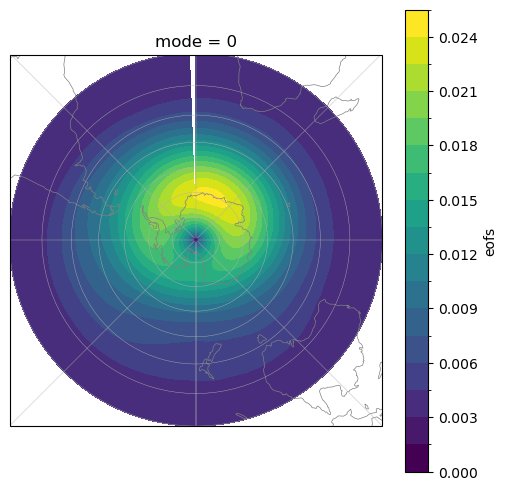

In [393]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = eof1.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

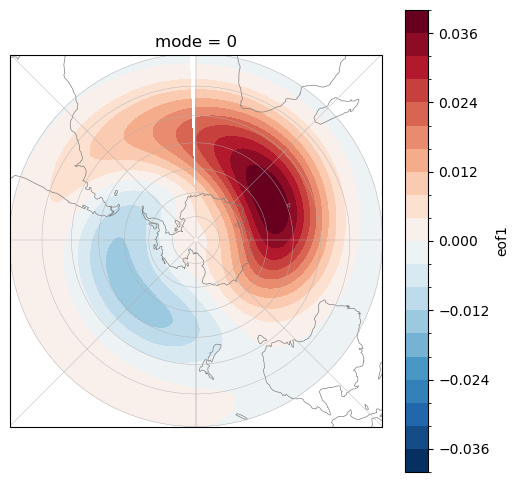

In [411]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = original_eof.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

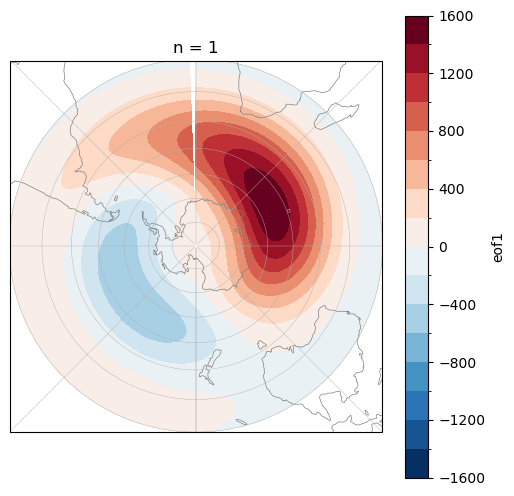

In [407]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = original_eof.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

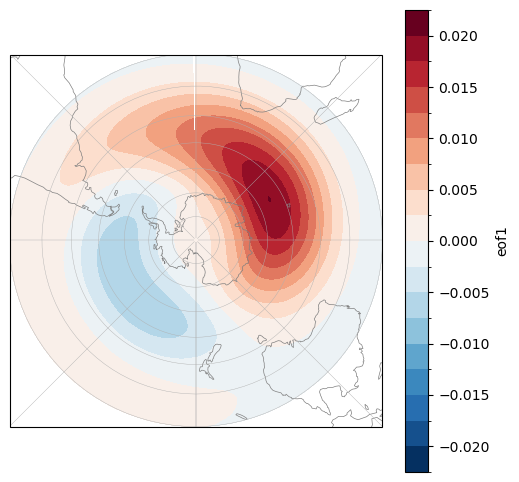

In [397]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = original_eof.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

2. project daily z anom timeseries onto monthly eof

... let's do it year by year

In [221]:
# compute climatology for a given year

In [266]:
month = 6
target_pa = 1000.0  # 10 hPa in Pa
lat_lo, lat_hi = -90, -20

def _preproc(ds):
    # robust lat slice regardless of ascending/descending order
    lat = ds["lat"]
    if lat[0] > lat[-1]:
        ds = ds.sel(lat=slice(lat_hi, lat_lo))   # descending
    else:
        ds = ds.sel(lat=slice(lat_lo, lat_hi))   # ascending
    # pick level & thin lon like NCL (every 2nd point)
    ds = ds.sel(plev=target_pa, method="nearest")
    # keep just the variable of interest (adjust name)
    return ds[["var129"]]


In [267]:
def compute_clim(month):
    files = sorted(glob.glob(str(gh_dir/ f"era5_an_geopot_reg2_6h_*{month:02d}.nc")))

    # open datasets
    ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    parallel=True,
    preprocess=_preproc,
    chunks={"time": 365, "lat": -1, "lon": -1, "plev": 1},
    engine="netcdf4",  # or "h5netcdf"—try both if speed matters
)

    # convert geopotential (m^2 s^-2) -> height (m), if needed
    z = ds["var129"]
    z = z/9.81

    # take daily mean
    daily = z.groupby("time.date").mean()              # dims: date, lat, lon
    daily = daily.rename({"date": "time"})
    daily = daily.assign_coords(time=daily.time.astype("datetime64[ns]"))
    daily = daily.sel(time=~((daily.time.dt.month == 2) & (daily.time.dt.day == 29)))

    # compute clim
    base = daily.sel(time=slice("1981", "2023"))
    clim = base.groupby("time.day").mean("time").persist()
    
    return clim

In [268]:
clim = compute_clim(month)

In [269]:
clim

<xarray.DataArray 'var129' (day: 30, lat: 36, lon: 180)> Size: 778kB
dask.array<transpose, shape=(30, 36, 180), dtype=float32, chunksize=(30, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev     float64 8B 1e+03
  * day      (day) int64 240B 1 2 3 4 5 6 7 8 9 ... 22 23 24 25 26 27 28 29 30

In [295]:
def compute_anom(ghfile, clim):
    gh_single = xr.open_dataset(gh_file)

    gh_single = gh_single['var129'].resample(time="1D").mean()
    gh_single = gh_single.sel(plev=target_pa, lat=slice(lat_hi, lat_lo))/9.81

    gh_anom = gh_single - clim.values
    return gh_anom

In [296]:
gh_file = str(gh_dir/ f"era5_an_geopot_reg2_6h_1979{month:02d}.nc")

In [297]:
gh_anom = compute_anom(gh_file, clim)

In [298]:
# weighted gh anom

In [299]:
w = xr.apply_ufunc(np.cos, np.deg2rad(gh_anom["lat"])) ** 0.5
w2d = w.broadcast_like(eof1)

In [300]:
gh_anom = gh_anom*w2d